# 04 - Exploratory Data Analysis (EDA)
**Project:** Ứng dụng Khoa học dữ liệu đa yếu tố trong phân tích, dự đoán và cảnh báo sớm nguy cơ học tập kém của sinh viên
**Dataset:** `dataset_with_risk.csv` (6,606 sinh viên, đã làm sạch, có nhãn `Risk_Level`)
**Target:** `Risk_Level` (High / Medium / Low), tạo từ `Exam_Score` theo quartile (< 65 High, < 69 Medium, còn lại Low)

---
### TABLE OF CONTENTS
1. **Environment Setup & Data Loading**
2. **Univariate Analysis** (Numerical & Categorical)
3. **Feature ↔ Feature Analysis** (Correlation & Multicollinearity)
4. **Feature ↔ Target Analysis** (Group Comparison)
5. **Categorical ↔ Numerical Analysis**
6. **Categorical ↔ Categorical Analysis** (Crosstab)
7. **Multivariate Analysis** (Pair Plot)
8. **Outlier Analysis & Log Transformation**
9. **Class Imbalance Analysis & Modeling Recommendations**
10. **Cluster Analysis** (K-Means)
11. **Feature Engineering Analysis**
12. **Feature Evaluation Summary** (4-Panel Overview)
13. **Business Insights & Executive Dashboard**

## 1. Environment Setup & Data Loading

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

TARGET = "Risk_Level"
RISK_ORDER = ["High", "Medium", "Low"]
PALETTE = {"High": "#d9534f", "Medium": "#f0ad4e", "Low": "#5cb85c"}

In [2]:
# Tự tìm file dữ liệu: Google Drive (Colab) -> thư mục trong repo -> thư mục hiện tại
CANDIDATES = [
    Path("/content/drive/MyDrive/Data science/01-Datasheet"),
    Path("data/processed"), Path("../data/processed"),
    Path("data/raw"), Path("../data/raw"),
    Path("data"), Path("."), Path("/mnt/user-data/uploads"),
]

def find(name):
    for d in CANDIDATES:
        if (d / name).exists():
            return d / name
    return None

CLEAN = find("dataset_with_risk.csv")
RAW = find("StudentPerformanceFactors.csv")   # chỉ dùng để thống kê missing ban đầu
KMEANS_PKL = find("kmeans_model.pkl")         # chỉ dùng để đối chiếu cụm
assert CLEAN is not None, "Không tìm thấy dataset_with_risk.csv - hãy sửa CANDIDATES"

FIG_DIR = Path("docs/figures")                # biểu đồ lưu tại đây để chèn vào báo cáo
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")

print("Clean:", CLEAN)
print("Raw  :", RAW)
print("KMeans:", KMEANS_PKL)

Clean: /mnt/user-data/uploads/dataset_with_risk.csv
Raw  : /mnt/user-data/uploads/StudentPerformanceFactors.csv
KMeans: /mnt/user-data/uploads/kmeans_model.pkl


In [3]:
df = pd.read_csv(CLEAN)
raw = pd.read_csv(RAW) if RAW else None
print(f"Clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.info()

Clean dataset: 6,606 rows x 26 columns
<class 'pandas.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hours_Studied                          6606 non-null   int64  
 1   Attendance                             6606 non-null   int64  
 2   Parental_Involvement                   6606 non-null   int64  
 3   Access_to_Resources                    6606 non-null   int64  
 4   Extracurricular_Activities             6606 non-null   int64  
 5   Sleep_Hours                            6606 non-null   int64  
 6   Previous_Scores                        6606 non-null   int64  
 7   Motivation_Level                       6606 non-null   int64  
 8   Internet_Access                        6606 non-null   int64  
 9   Tutoring_Sessions                      6606 non-null   int64  
 10  Family_Income                          6606 

In [4]:
df.describe().T.round(2)

                             count   mean    std  ...    50%   75%    max
Hours_Studied               6606.0  19.97   5.99  ...  20.00  24.0   44.0
Attendance                  6606.0  79.97  11.55  ...  80.00  90.0  100.0
Parental_Involvement        6606.0   1.09   0.70  ...   1.00   2.0    2.0
Access_to_Resources         6606.0   1.10   0.70  ...   1.00   2.0    2.0
Extracurricular_Activities  6606.0   0.60   0.49  ...   1.00   1.0    1.0
Sleep_Hours                 6606.0   7.03   1.47  ...   7.00   8.0   10.0
Previous_Scores             6606.0  75.07  14.40  ...  75.00  88.0  100.0
Motivation_Level            6606.0   0.91   0.70  ...   1.00   1.0    2.0
Internet_Access             6606.0   0.92   0.26  ...   1.00   1.0    1.0
Tutoring_Sessions           6606.0   1.49   1.23  ...   1.00   2.0    8.0
Family_Income               6606.0   0.79   0.74  ...   1.00   1.0    2.0
Teacher_Quality             6606.0   1.20   0.60  ...   1.00   2.0    2.0
School_Type                 6606.0   0

In [5]:
print("=== MISSING VALUES (clean dataset) ===")
print(f"Tổng số ô thiếu: {int(df.isnull().sum().sum())}")
print(f"Duplicate ratio (clean): {df.duplicated().sum() / len(df) * 100:.2f}%")

if raw is not None:
    miss = raw.isnull().sum()
    miss = miss[miss > 0]
    print(f"\n=== MISSING VALUES (raw, {len(raw):,} rows) ===")
    print(pd.DataFrame({"missing": miss, "ratio_%": (miss / len(raw) * 100).round(2)}))
    print(f"Duplicate ratio (raw): {raw.duplicated().sum() / len(raw) * 100:.2f}%")

=== MISSING VALUES (clean dataset) ===
Tổng số ô thiếu: 0
Duplicate ratio (clean): 0.00%

=== MISSING VALUES (raw, 6,607 rows) ===
                          missing  ratio_%
Teacher_Quality                78     1.18
Parental_Education_Level       90     1.36
Distance_from_Home             67     1.01
Duplicate ratio (raw): 0.00%


## 2. Univariate Analysis (Numerical & Categorical)

### 2.1 Numerical Features (Histplot + KDE)

                    mean  median    std   min    max  skew
Hours_Studied      19.97    20.0   5.99   1.0   44.0  0.01
Attendance         79.97    80.0  11.55  60.0  100.0  0.01
Sleep_Hours         7.03     7.0   1.47   4.0   10.0 -0.02
Previous_Scores    75.07    75.0  14.40  50.0  100.0 -0.00
Tutoring_Sessions   1.49     1.0   1.23   0.0    8.0  0.81
Physical_Activity   2.97     3.0   1.03   0.0    6.0 -0.03
Exam_Score         67.23    67.0   3.87  55.0  100.0  1.58


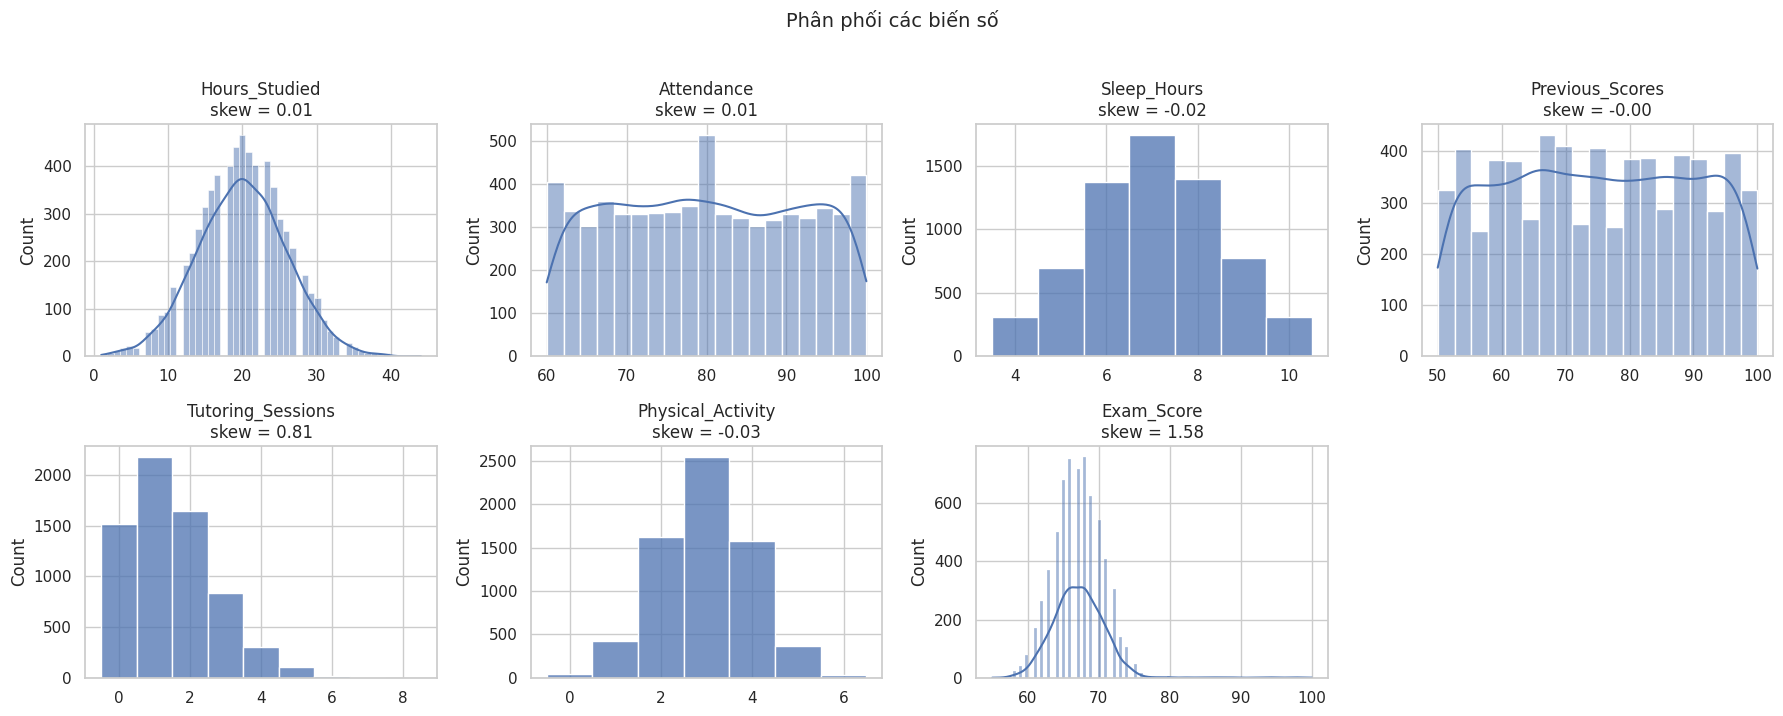

In [6]:
NUM_COLS = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
            "Tutoring_Sessions", "Physical_Activity", "Exam_Score"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
for ax, col in zip(axes, NUM_COLS):
    discrete = df[col].nunique() <= 12
    sns.histplot(df[col], kde=not discrete, discrete=discrete, ax=ax, color="#4c72b0")
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}")
    ax.set_xlabel("")
axes[-1].axis("off")
plt.suptitle("Phân phối các biến số", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("02_numeric_distributions")
plt.show()

print(df[NUM_COLS].agg(["mean", "median", "std", "min", "max", "skew"]).T.round(2))

**Nhận xét:** Hầu hết biến số có phân phối **đối xứng** (skew ≈ 0). Chỉ `Exam_Score` (lệch phải) và `Tutoring_Sessions` (lệch phải nhẹ) lệch rõ rệt. Điểm thi tập trung quanh 65–69.

### 2.2 Categorical Features (Countplot)

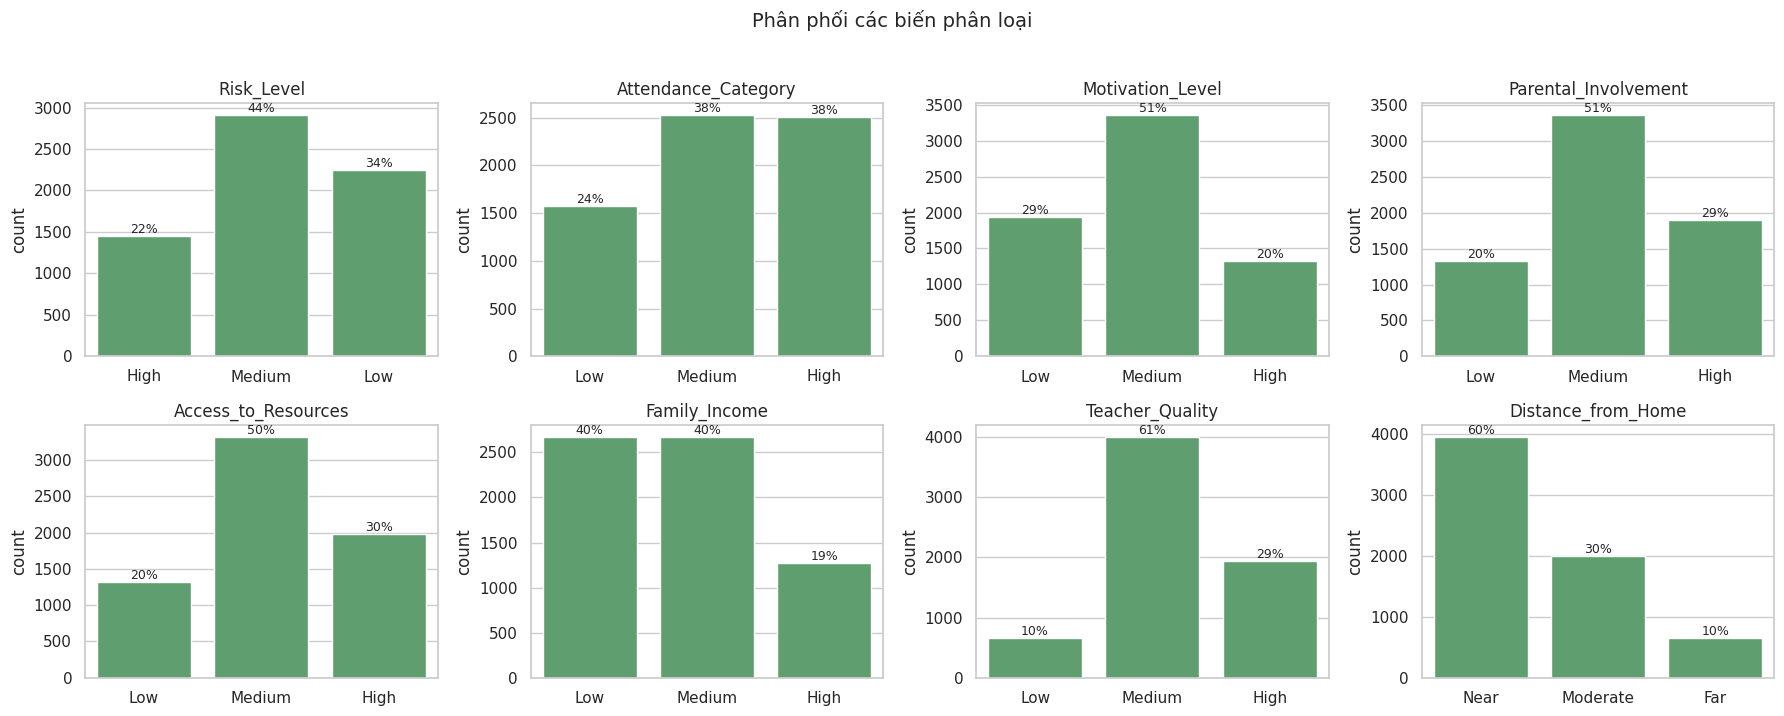

In [7]:
ORD = {0: "Low", 1: "Medium", 2: "High"}
DIST = {0: "Near", 1: "Moderate", 2: "Far"}

cat_views = {
    "Risk_Level": (df["Risk_Level"], RISK_ORDER),
    "Attendance_Category": (df["Attendance_Category"], ["Low", "Medium", "High"]),
    "Motivation_Level": (df["Motivation_Level"].map(ORD), ["Low", "Medium", "High"]),
    "Parental_Involvement": (df["Parental_Involvement"].map(ORD), ["Low", "Medium", "High"]),
    "Access_to_Resources": (df["Access_to_Resources"].map(ORD), ["Low", "Medium", "High"]),
    "Family_Income": (df["Family_Income"].map(ORD), ["Low", "Medium", "High"]),
    "Teacher_Quality": (df["Teacher_Quality"].map(ORD), ["Low", "Medium", "High"]),
    "Distance_from_Home": (df["Distance_from_Home"].map(DIST), ["Near", "Moderate", "Far"]),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, (name, (series, order)) in zip(axes.ravel(), cat_views.items()):
    sns.countplot(x=series, order=order, ax=ax, color="#55a868")
    ax.set_title(name)
    ax.set_xlabel("")
    for p in ax.patches:
        ax.annotate(f"{p.get_height() / len(df) * 100:.0f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Phân phối các biến phân loại", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("02_categorical_counts")
plt.show()

## 3. Feature ↔ Feature Analysis (Correlation & Multicollinearity)

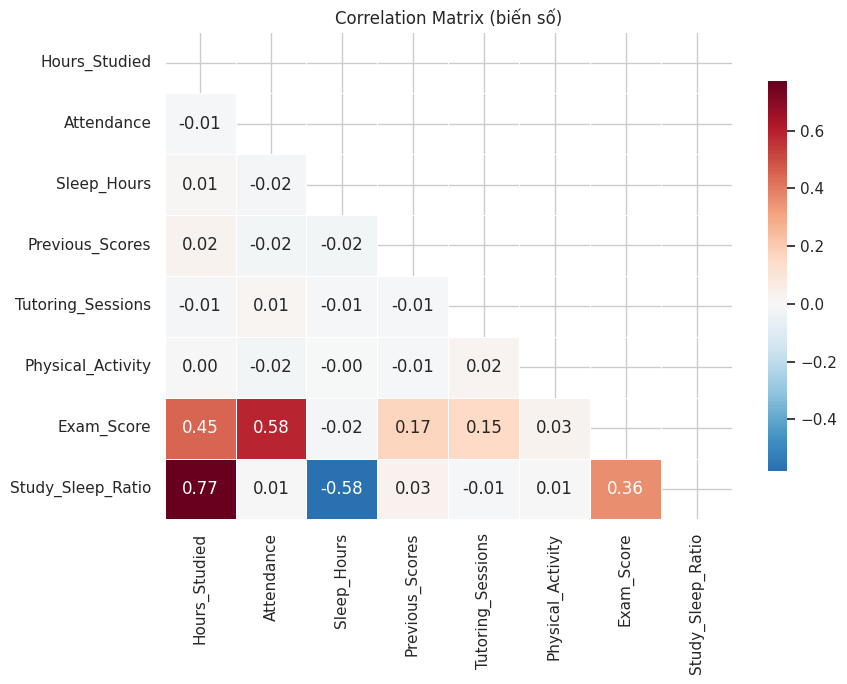

In [8]:
corr_cols = NUM_COLS + ["Study_Sleep_Ratio"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, mask=mask,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (biến số)")
plt.tight_layout()
save_fig("03_correlation_heatmap")
plt.show()

Attendance                               0.582
Hours_Studied                            0.447
Study_Sleep_Ratio                        0.358
Previous_Scores                          0.174
Access_to_Resources                      0.171
Parental_Involvement                     0.160
Tutoring_Sessions                        0.154
Cluster                                  0.109
Parental_Education_Level_Postgraduate    0.095
Family_Income                            0.093
Name: Exam_Score, dtype: float64


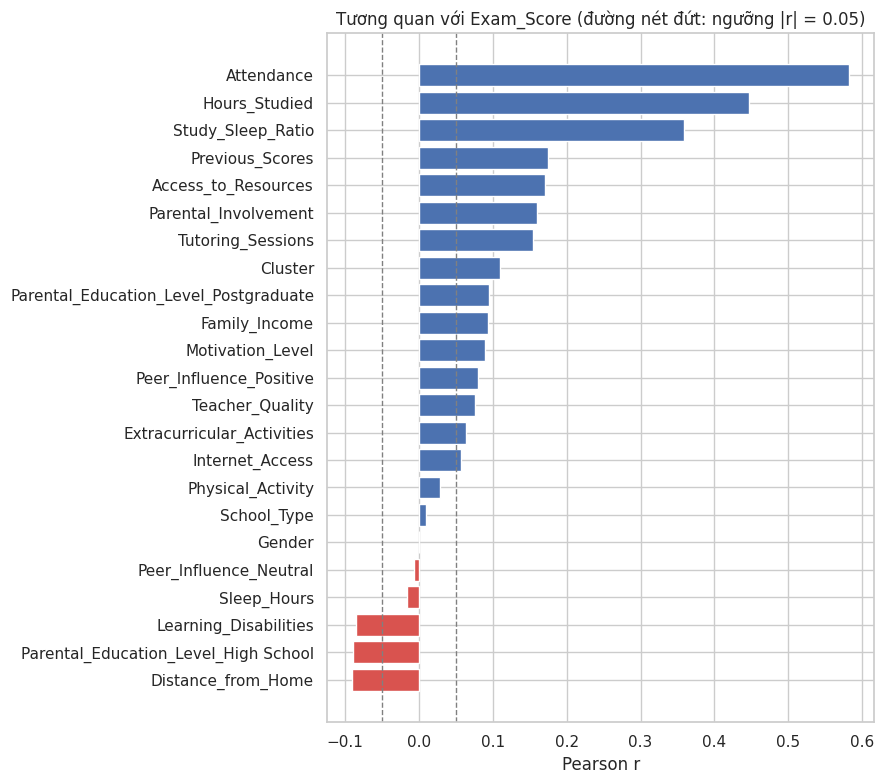

In [9]:
# Tương quan của TẤT CẢ feature với Exam_Score
num_df = df.select_dtypes(include=["number", "bool"]).astype(float)
corr_target = num_df.corr()["Exam_Score"].drop(["Exam_Score"]).sort_values()

plt.figure(figsize=(9, 8))
colors = ["#d9534f" if v < 0 else "#4c72b0" for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0.05, color="gray", ls="--", lw=1)
plt.axvline(-0.05, color="gray", ls="--", lw=1)
plt.title("Tương quan với Exam_Score (đường nét đứt: ngưỡng |r| = 0.05)")
plt.xlabel("Pearson r")
plt.tight_layout()
save_fig("03_correlation_with_target")
plt.show()

print(corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).round(3).head(10))

In [10]:
# Đa cộng tuyến giữa các feature (không tính Exam_Score)
feat_corr = num_df.drop(columns=["Exam_Score"]).corr()
pairs = (feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
         .stack().rename("r").reset_index())
pairs["abs_r"] = pairs["r"].abs()
print("=== Cặp feature có |r| cao nhất ===")
print(pairs.sort_values("abs_r", ascending=False).head(5).round(3).to_string(index=False))

=== Cặp feature có |r| cao nhất ===
                             level_0                               level_1      r  abs_r
                       Hours_Studied                     Study_Sleep_Ratio  0.771  0.771
                         Sleep_Hours                               Cluster  0.694  0.694
              Peer_Influence_Neutral               Peer_Influence_Positive -0.655  0.655
                         Sleep_Hours                     Study_Sleep_Ratio -0.578  0.578
Parental_Education_Level_High School Parental_Education_Level_Postgraduate -0.498  0.498


**Nhận xét:** `Attendance` (r ≈ 0.58) và `Hours_Studied` (r ≈ 0.45) là hai yếu tố tương quan mạnh nhất với điểm thi. `Sleep_Hours`, `Physical_Activity`, `Gender`, `School_Type` gần như không tương quan. Các feature gốc gần như **độc lập với nhau**; các cặp tương quan cao đều xuất phát từ biến phái sinh hoặc biến dummy: `Study_Sleep_Ratio` (tính từ `Hours_Studied` / `Sleep_Hours`), `Cluster` (tạo từ `Sleep_Hours`) và cặp `Peer_Influence_*`.

## 4. Feature ↔ Target Analysis (Group Comparison)

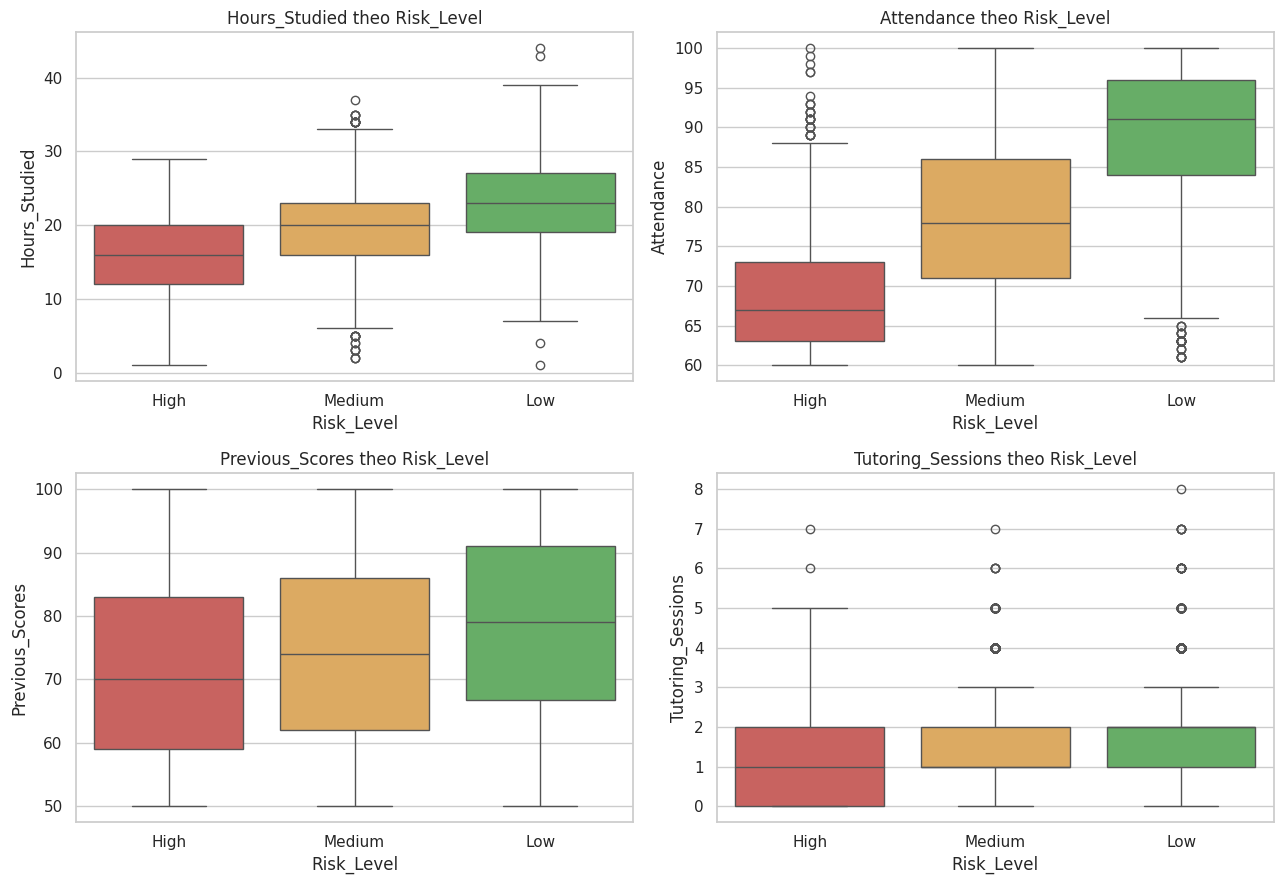

In [11]:
KEY_FEATS = ["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), KEY_FEATS):
    sns.boxplot(data=df, x=TARGET, y=col, order=RISK_ORDER, hue=TARGET,
                palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f"{col} theo {TARGET}")
plt.tight_layout()
save_fig("04_feature_vs_target_boxplot")
plt.show()

In [12]:
cmp_cols = ["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions",
            "Sleep_Hours", "Physical_Activity"]
print("=== Trung bình theo nhóm nguy cơ ===")
print(df.groupby(TARGET)[cmp_cols].mean().loc[RISK_ORDER].round(2))

print("\n=== Kiểm định Kruskal-Wallis (khác biệt giữa 3 nhóm) ===")
rows = []
for c in cmp_cols:
    groups = [df.loc[df[TARGET] == g, c] for g in RISK_ORDER]
    h, p = stats.kruskal(*groups)
    rows.append({"feature": c, "H": round(h, 1), "p_value": f"{p:.2e}", "khác biệt (p<0.05)": p < 0.05})
print(pd.DataFrame(rows).to_string(index=False))

=== Trung bình theo nhóm nguy cơ ===
            Hours_Studied  Attendance  ...  Sleep_Hours  Physical_Activity
Risk_Level                             ...                                
High                15.91       69.23  ...         7.04               2.89
Medium              19.59       78.42  ...         7.03               2.99
Low                 23.10       88.92  ...         7.02               2.98

[3 rows x 6 columns]

=== Kiểm định Kruskal-Wallis (khác biệt giữa 3 nhóm) ===
          feature      H   p_value  khác biệt (p<0.05)
    Hours_Studied 1269.9 1.79e-276                True
       Attendance 2657.7  0.00e+00                True
  Previous_Scores  203.8  5.43e-45                True
Tutoring_Sessions  152.5  7.61e-34                True
      Sleep_Hours    0.1  9.30e-01               False
Physical_Activity    8.6  1.35e-02                True


**Nhận xét:** `Hours_Studied`, `Attendance`, `Previous_Scores`, `Tutoring_Sessions` tăng dần từ nhóm High → Low, khác biệt có ý nghĩa thống kê. `Sleep_Hours` gần như bằng nhau ở cả 3 nhóm.

## 5. Categorical ↔ Numerical Analysis

=== Điểm thi trung bình theo nhóm ===
{'Low': 66.33, 'Medium': 67.1, 'High': 68.09}
{'Low': 66.73, 'Medium': 67.33, 'High': 67.7}
{'Low': 66.2, 'Medium': 67.12, 'High': 68.09}
{'Low': 66.85, 'Medium': 67.33, 'High': 67.82}
{'No': 67.34, 'Yes': 66.27}


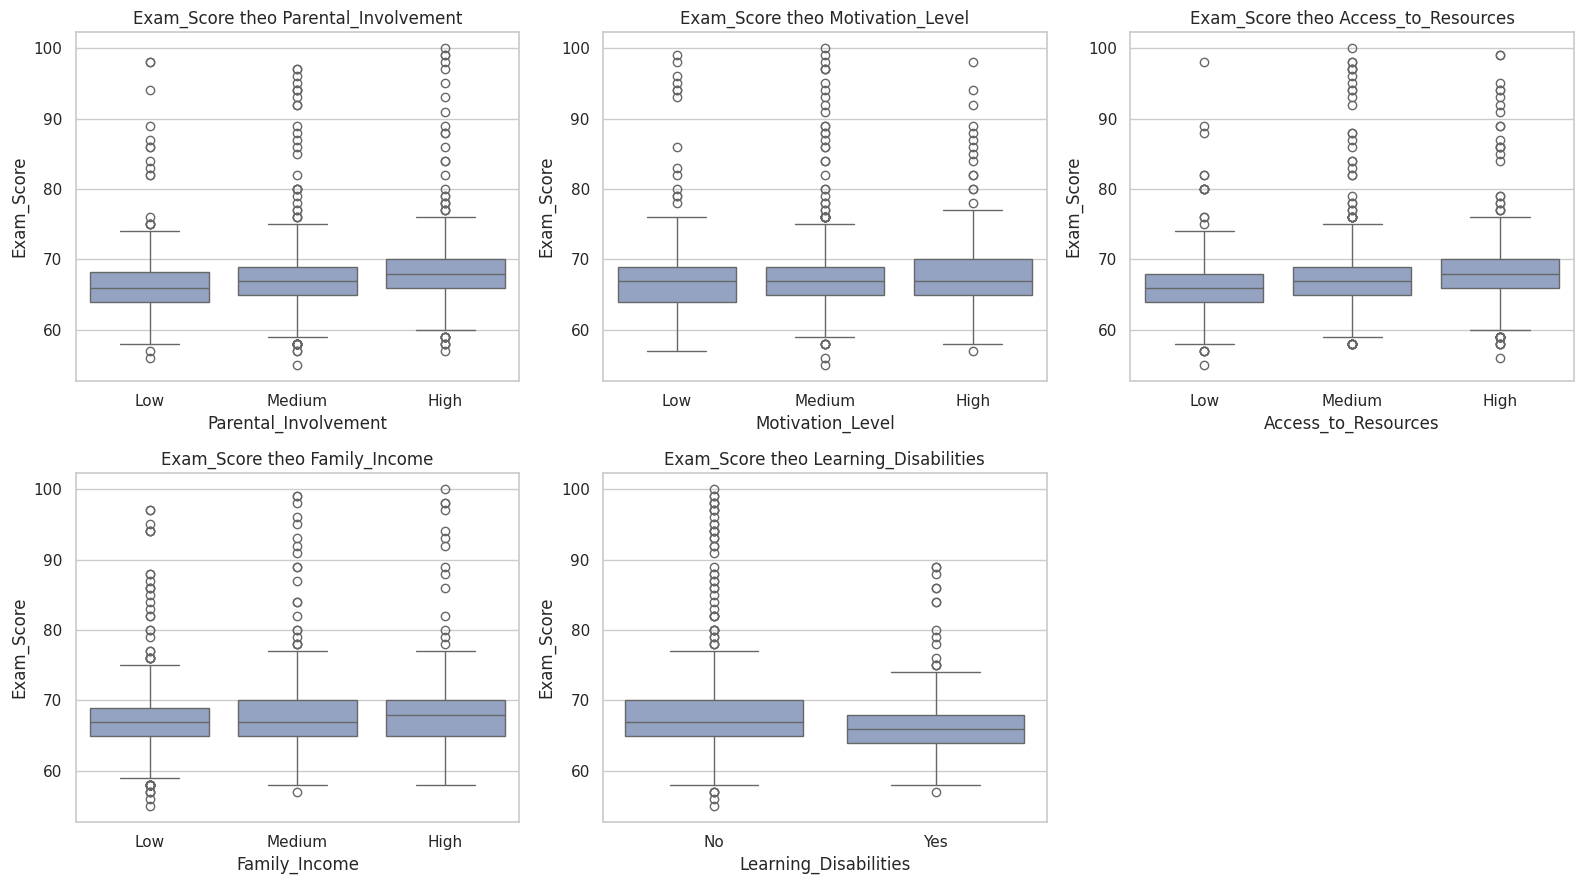

In [13]:
view = df.copy()
for c in ["Parental_Involvement", "Motivation_Level", "Access_to_Resources", "Family_Income"]:
    view[c] = view[c].map(ORD)
view["Learning_Disabilities"] = view["Learning_Disabilities"].map({0: "No", 1: "Yes"})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plots = [("Parental_Involvement", ["Low", "Medium", "High"]),
         ("Motivation_Level", ["Low", "Medium", "High"]),
         ("Access_to_Resources", ["Low", "Medium", "High"]),
         ("Family_Income", ["Low", "Medium", "High"]),
         ("Learning_Disabilities", ["No", "Yes"])]
for ax, (col, order) in zip(axes.ravel(), plots):
    sns.boxplot(data=view, x=col, y="Exam_Score", order=order, ax=ax, color="#8da0cb")
    ax.set_title(f"Exam_Score theo {col}")
axes.ravel()[-1].axis("off")
plt.tight_layout()
save_fig("05_score_by_category")
plt.show()

print("=== Điểm thi trung bình theo nhóm ===")
for col, order in plots:
    print(view.groupby(col)["Exam_Score"].mean().reindex(order).round(2).to_dict())

**Nhận xét:** Các yếu tố gia đình và trường học có quan hệ **đơn điệu** với điểm thi (mức càng cao, điểm càng cao), nhưng chênh lệch giữa nhóm thấp và cao chỉ khoảng **1–2 điểm**, nhỏ hơn nhiều so với tác động của chuyên cần và giờ học.

## 6. Categorical ↔ Categorical Analysis (Crosstab)

=== Risk_Level theo Attendance_Category (%) ===
Risk_Level           High  Medium   Low
Attendance_Category                    
Low                  56.1    39.4   4.5
Medium               20.1    58.5  21.4
High                  2.5    32.3  65.3


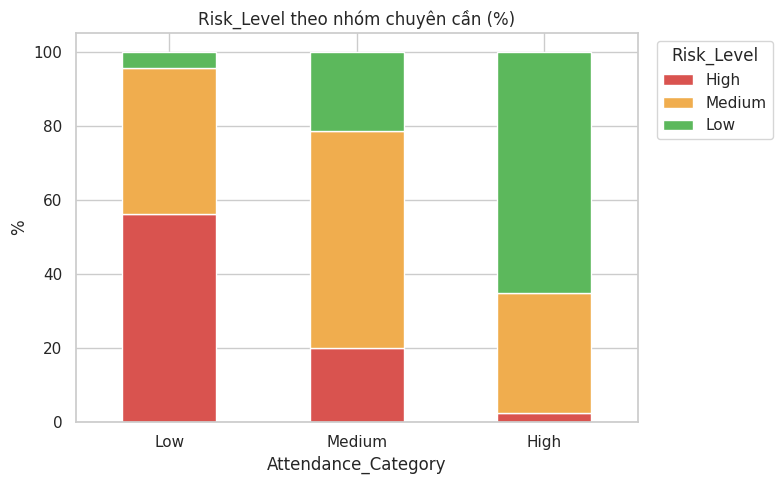

In [14]:
ct = pd.crosstab(df["Attendance_Category"], df[TARGET], normalize="index")[RISK_ORDER] * 100
ct = ct.loc[["Low", "Medium", "High"]]
print("=== Risk_Level theo Attendance_Category (%) ===")
print(ct.round(1))

ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5), color=[PALETTE[c] for c in RISK_ORDER], rot=0)
ax.set_title("Risk_Level theo nhóm chuyên cần (%)")
ax.set_xlabel("Attendance_Category")
ax.set_ylabel("%")
plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig("06_risk_by_attendance_category")
plt.show()

=== Risk_Level theo Cluster (%) ===
Risk_Level  High  Medium   Low
Cluster                       
0           36.2    49.9  13.9
1            4.7    36.0  59.3
2           28.0    47.6  24.4


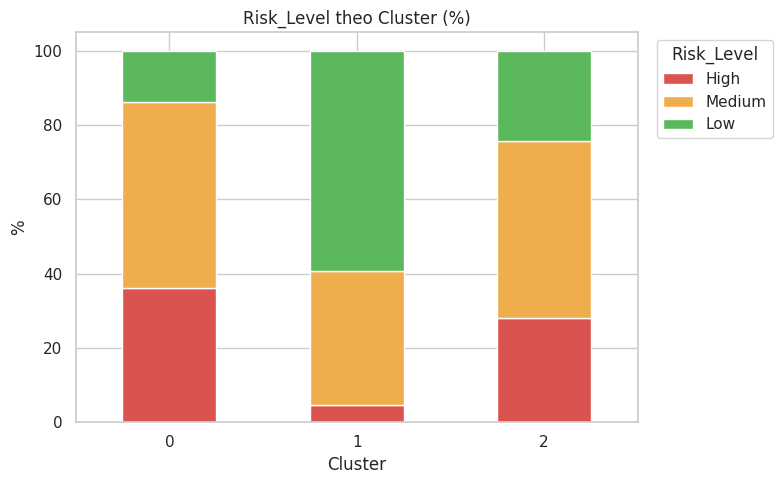

In [15]:
ct2 = pd.crosstab(df["Cluster"], df[TARGET], normalize="index")[RISK_ORDER] * 100
print("=== Risk_Level theo Cluster (%) ===")
print(ct2.round(1))

ax = ct2.plot(kind="bar", stacked=True, figsize=(8, 5), color=[PALETTE[c] for c in RISK_ORDER], rot=0)
ax.set_title("Risk_Level theo Cluster (%)")
ax.set_ylabel("%")
plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig("06_risk_by_cluster")
plt.show()

**Nhận xét:** Chuyên cần là yếu tố phân tầng rõ nhất. Nhóm chuyên cần thấp (< 70%) có hơn một nửa sinh viên thuộc nguy cơ cao, trong khi nhóm chuyên cần cao (≥ 85%) chỉ có khoảng 2–3%.

## 7. Multivariate Analysis (Pair Plot)

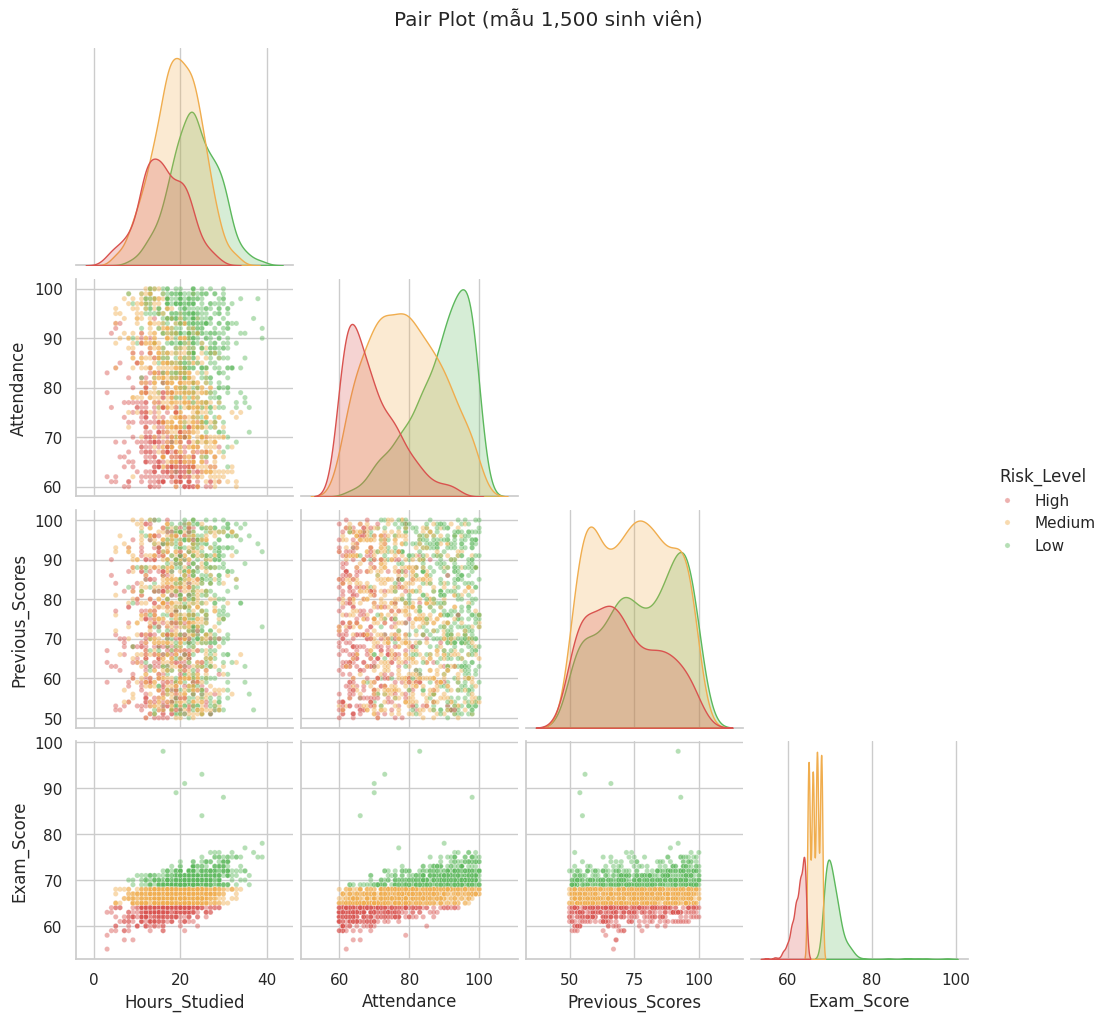

In [16]:
pair_cols = ["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score"]
sample = df[pair_cols + [TARGET]].sample(1500, random_state=42)

g = sns.pairplot(sample, vars=pair_cols, hue=TARGET, hue_order=RISK_ORDER,
                 palette=PALETTE, corner=True, plot_kws={"alpha": 0.45, "s": 14},
                 diag_kind="kde")
g.fig.suptitle("Pair Plot (mẫu 1,500 sinh viên)", y=1.02)
g.fig.savefig(FIG_DIR / "07_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Outlier Analysis & Log Transformation

          feature  lower  upper  n_outliers    %
    Hours_Studied    4.0   36.0          43 0.65
       Attendance   40.0  120.0           0 0.00
      Sleep_Hours    3.0   11.0           0 0.00
  Previous_Scores   25.5  125.5           0 0.00
Tutoring_Sessions   -0.5    3.5         429 6.49
Physical_Activity   -1.0    7.0           0 0.00
       Exam_Score   59.0   75.0         103 1.56


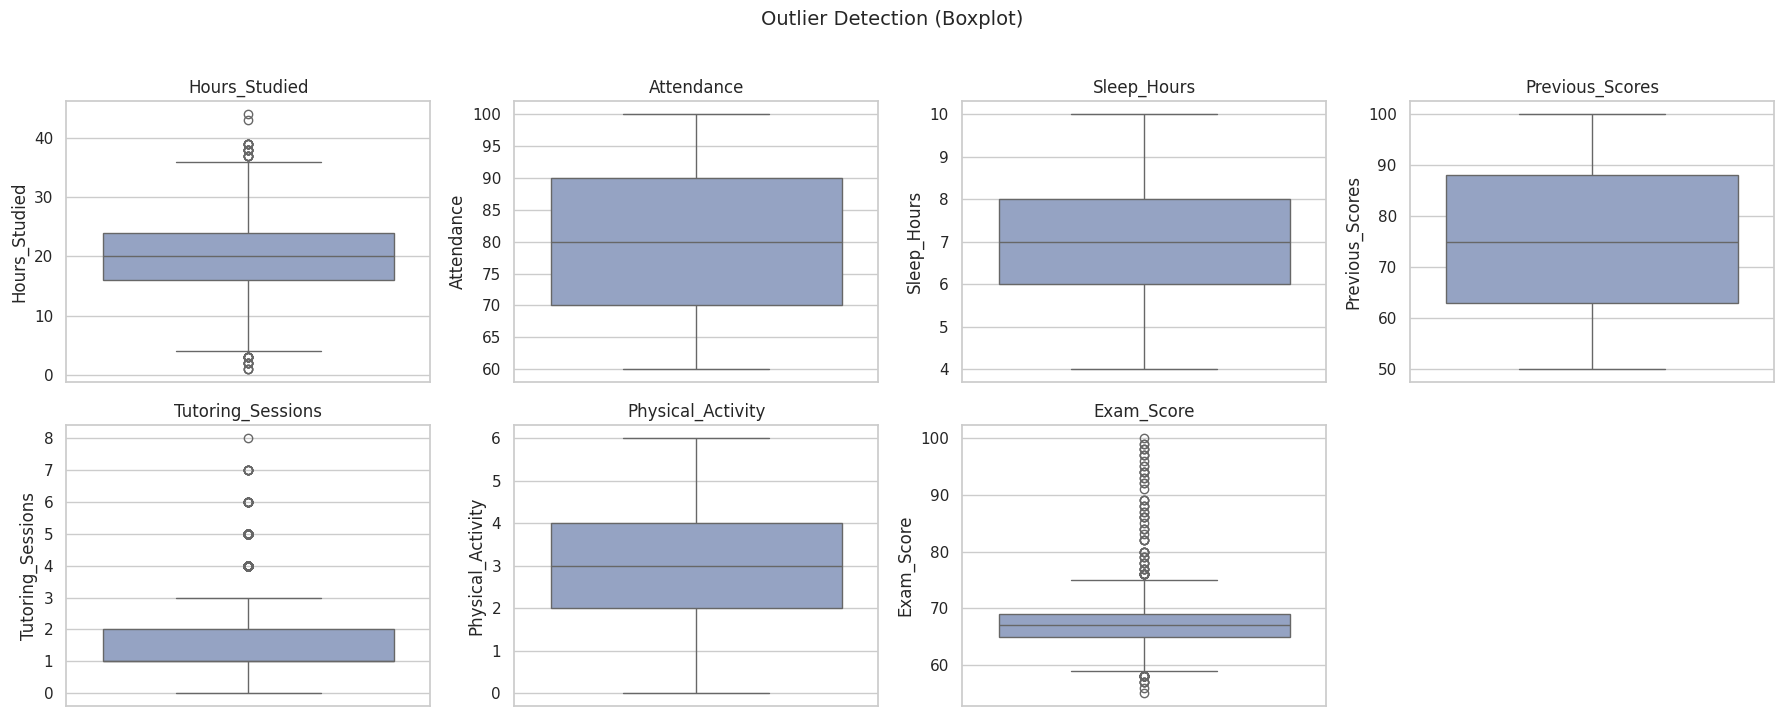

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(y=df[col], ax=ax, color="#8da0cb")
    ax.set_title(col)
axes[-1].axis("off")
plt.suptitle("Outlier Detection (Boxplot)", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("08_outlier_boxplots")
plt.show()

rows = []
for col in NUM_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    rows.append({"feature": col, "lower": round(lo, 1), "upper": round(hi, 1),
                 "n_outliers": n_out, "%": round(n_out / len(df) * 100, 2)})
print(pd.DataFrame(rows).to_string(index=False))

**Nhận xét:** Các giá trị ngoài khoảng IQR đều nằm trong miền hợp lệ về nghiệp vụ (điểm thi cao/thấp thật, số buổi học thêm nhiều), thuộc dạng **Genuine Extreme Value**, nên **giữ nguyên**.

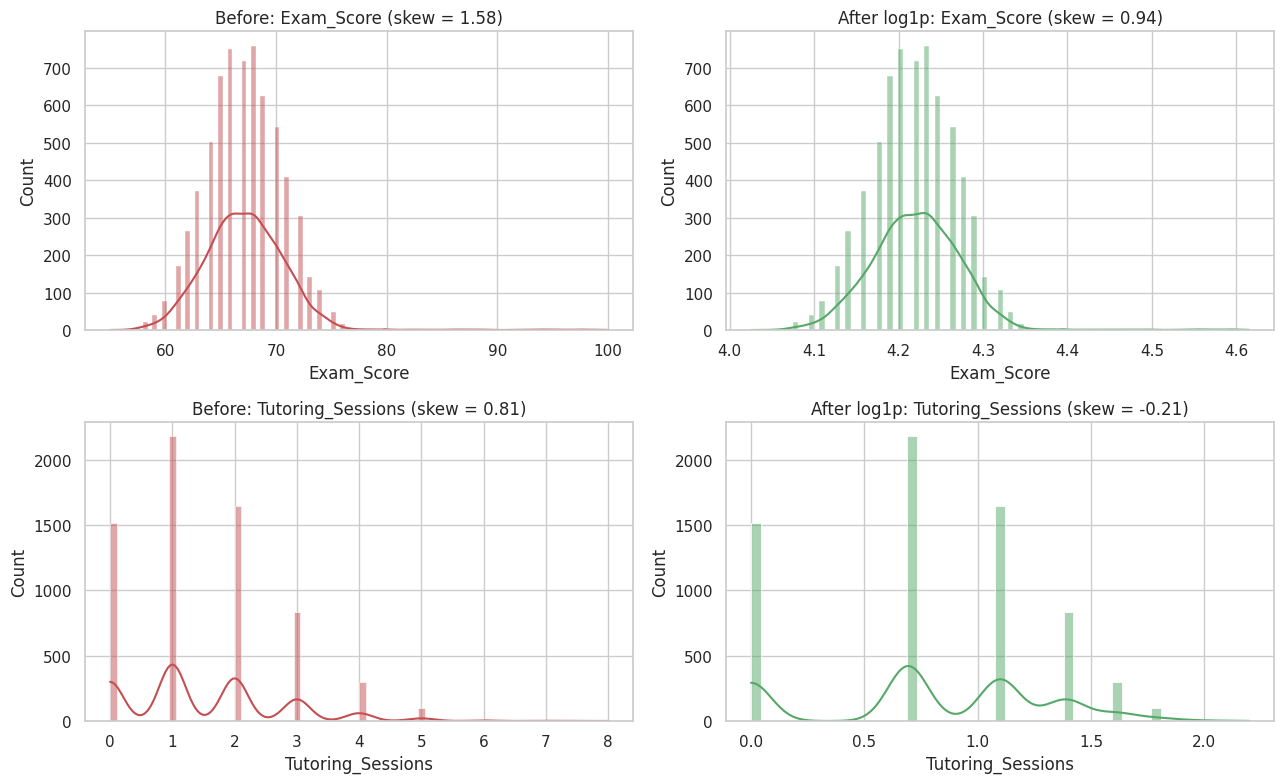

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, col in enumerate(["Exam_Score", "Tutoring_Sessions"]):
    data = df[col]
    data_log = np.log1p(data)
    sns.histplot(data, kde=True, ax=axes[row, 0], color="#c44e52")
    axes[row, 0].set_title(f"Before: {col} (skew = {data.skew():.2f})")
    sns.histplot(data_log, kde=True, ax=axes[row, 1], color="#55a868")
    axes[row, 1].set_title(f"After log1p: {col} (skew = {data_log.skew():.2f})")
plt.tight_layout()
save_fig("08_log_transform")
plt.show()

**Nhận xét:** Phép biến đổi `log1p` giảm độ lệch của `Exam_Score` (1.58 → 0.94) và `Tutoring_Sessions` (0.81 → -0.21). Tuy nhiên `Exam_Score` là nguồn tạo nhãn nên không đưa vào features, còn `Tutoring_Sessions` chỉ lệch nhẹ; việc biến đổi **không bắt buộc**, đặc biệt với mô hình dựa trên cây.

## 9. Class Imbalance Analysis & Modeling Recommendations

=== TARGET DISTRIBUTION ===
            count      %
Risk_Level              
High         1452  21.98
Medium       2906  43.99
Low          2248  34.03

Imbalance Ratio: 2906 / 1452 = 2.0 : 1

=== Khoảng Exam_Score của từng lớp ===
            min  max
Risk_Level          
High         55   64
Medium       65   68
Low          69  100


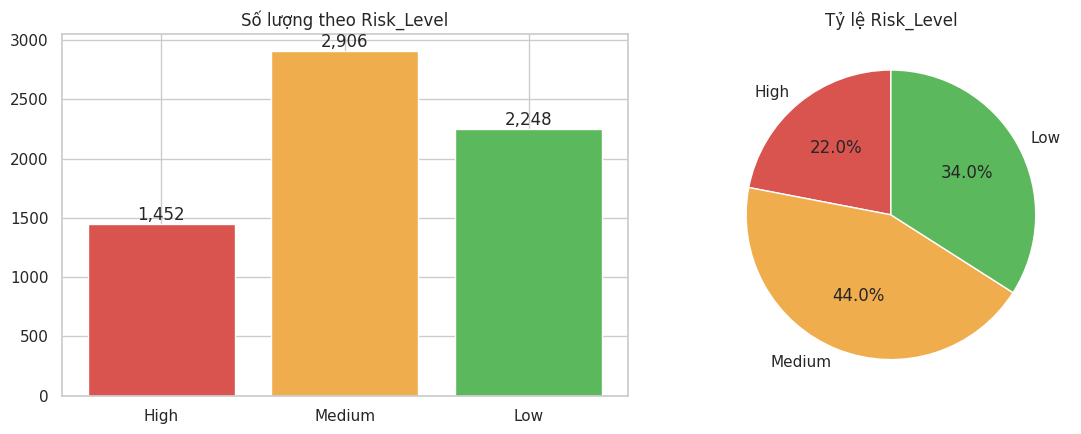

In [19]:
counts = df[TARGET].value_counts().reindex(RISK_ORDER)
print("=== TARGET DISTRIBUTION ===")
print(pd.DataFrame({"count": counts, "%": (counts / len(df) * 100).round(2)}))
print(f"\nImbalance Ratio: {counts.max()} / {counts.min()} = {counts.max() / counts.min():.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_title("Số lượng theo Risk_Level")
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[PALETTE[c] for c in counts.index], startangle=90)
axes[1].set_title("Tỷ lệ Risk_Level")
plt.tight_layout()
save_fig("09_class_distribution")
plt.show()

score_range = df.groupby(TARGET)["Exam_Score"].agg(["min", "max"]).loc[RISK_ORDER]
print("\n=== Khoảng Exam_Score của từng lớp ===")
print(score_range)

### Khuyến nghị cho Modeling
- Tỷ lệ lớp lớn nhất/nhỏ nhất chỉ khoảng **2 : 1**, mức mất cân bằng **nhẹ**. Chưa cần SMOTE; có thể dùng `class_weight="balanced"` nếu Recall của lớp High thấp.
- Chia Train/Test bằng `stratify=y` để giữ tỷ lệ 3 lớp.
- Ưu tiên **Recall và F1 của lớp High** (bỏ sót sinh viên nguy cơ cao là lỗi tốn kém nhất), kèm F1-Macro và ROC-AUC; không chỉ dựa vào Accuracy.
- **Không đưa `Exam_Score` vào features** vì nhãn `Risk_Level` được tính trực tiếp từ cột này (data leakage).

## 10. Cluster Analysis (K-Means)

{2: 0.19, 3: 0.174, 4: 0.179, 5: 0.181, 6: 0.175}


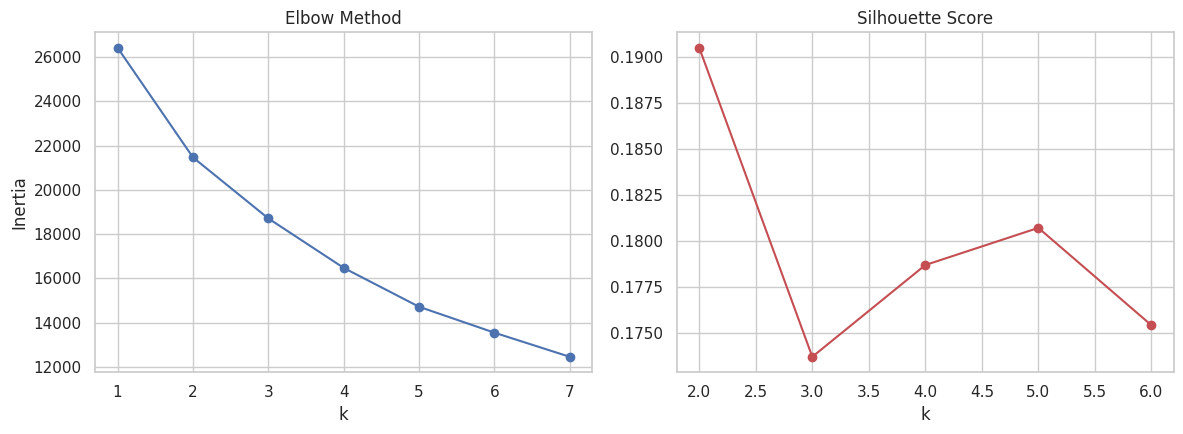

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

CLUSTER_FEATS = ["Hours_Studied", "Attendance", "Sleep_Hours", "Physical_Activity"]
Xc = StandardScaler().fit_transform(df[CLUSTER_FEATS])

ks = range(1, 8)
inertia = [KMeans(k, random_state=42, n_init=10).fit(Xc).inertia_ for k in ks]
sil = {k: silhouette_score(Xc, KMeans(k, random_state=42, n_init=10).fit_predict(Xc)) for k in range(2, 7)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(ks), inertia, "o-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(sil), list(sil.values()), "o-", color="#c44e52")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
plt.tight_layout()
save_fig("10_kmeans_elbow_silhouette")
plt.show()
print({k: round(v, 3) for k, v in sil.items()})

In [21]:
# Đối chiếu cột Cluster có sẵn với mô hình K-Means đã lưu
km_fit = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xc)
agree = (km_fit.labels_ == df["Cluster"].values).mean()
print(f"Khớp giữa K-Means chạy lại và cột Cluster: {agree * 100:.1f}%")

if KMEANS_PKL is not None:
    try:
        import joblib
        km_saved = joblib.load(KMEANS_PKL)
        agree2 = (km_saved.predict(Xc) == df["Cluster"].values).mean()
        print(f"Khớp giữa kmeans_model.pkl và cột Cluster: {agree2 * 100:.1f}%")
    except Exception as e:
        print("Không đọc được kmeans_model.pkl:", type(e).__name__)

Khớp giữa K-Means chạy lại và cột Cluster: 100.0%
Khớp giữa kmeans_model.pkl và cột Cluster: 100.0%


=== Đặc điểm từng Cluster ===
            n  Hours_Studied  ...  Exam_Score  High_risk_pct
Cluster                       ...                           
0        2243          20.32  ...       65.60          36.25
1        2503          19.24  ...       69.27           4.71
2        1860          20.54  ...       66.45          28.01

[3 rows x 8 columns]


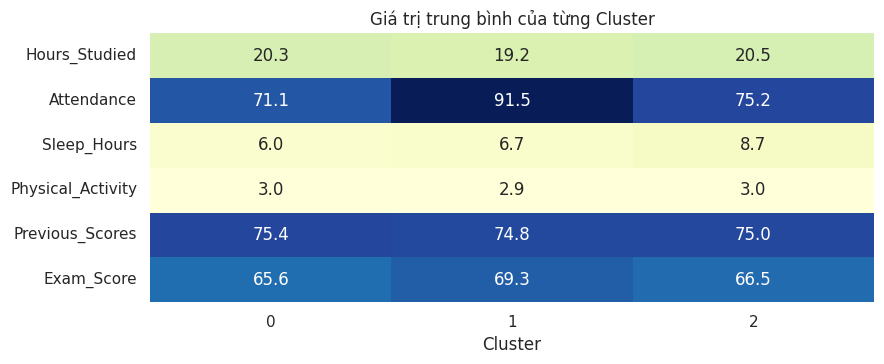

In [22]:
profile = df.groupby("Cluster").agg(
    n=("Exam_Score", "size"),
    Hours_Studied=("Hours_Studied", "mean"),
    Attendance=("Attendance", "mean"),
    Sleep_Hours=("Sleep_Hours", "mean"),
    Physical_Activity=("Physical_Activity", "mean"),
    Previous_Scores=("Previous_Scores", "mean"),
    Exam_Score=("Exam_Score", "mean"),
    High_risk_pct=(TARGET, lambda s: (s == "High").mean() * 100),
).round(2)
print("=== Đặc điểm từng Cluster ===")
print(profile)

z = (profile.drop(columns=["n", "High_risk_pct"]) - profile.drop(columns=["n", "High_risk_pct"]).mean()) \
    / profile.drop(columns=["n", "High_risk_pct"]).std()
plt.figure(figsize=(9, 3.8))
sns.heatmap(profile.drop(columns=["n", "High_risk_pct"]).T, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False)
plt.title("Giá trị trung bình của từng Cluster")
plt.tight_layout()
save_fig("10_cluster_profile")
plt.show()

**Nhận xét:**
- **Cụm 0** – chuyên cần thấp (~71%), ngủ ít (~6 giờ): nguy cơ cao nhất.
- **Cụm 1** – chuyên cần cao (~91%): nguy cơ thấp nhất, điểm cao nhất.
- **Cụm 2** – chuyên cần trung bình (~75%), ngủ nhiều (~8.7 giờ): nguy cơ trung gian.
- Giờ học và điểm kỳ trước gần như giống nhau giữa 3 cụm, nên **chuyên cần** là yếu tố phân biệt chính.
- Silhouette thấp (~0.17) và đồ thị Elbow không có "khuỷu" rõ: các cụm **tách nhau yếu**, nên dùng phân cụm để **mô tả** nhóm sinh viên, không coi là cấu trúc tự nhiên rõ ràng.

## 11. Feature Engineering Analysis

Study_Sleep_Ratio khớp công thức: True
Hours_Studied        0.447
Sleep_Hours         -0.016
Study_Sleep_Ratio    0.358
Exam_Score           1.000
Name: Exam_Score, dtype: float64


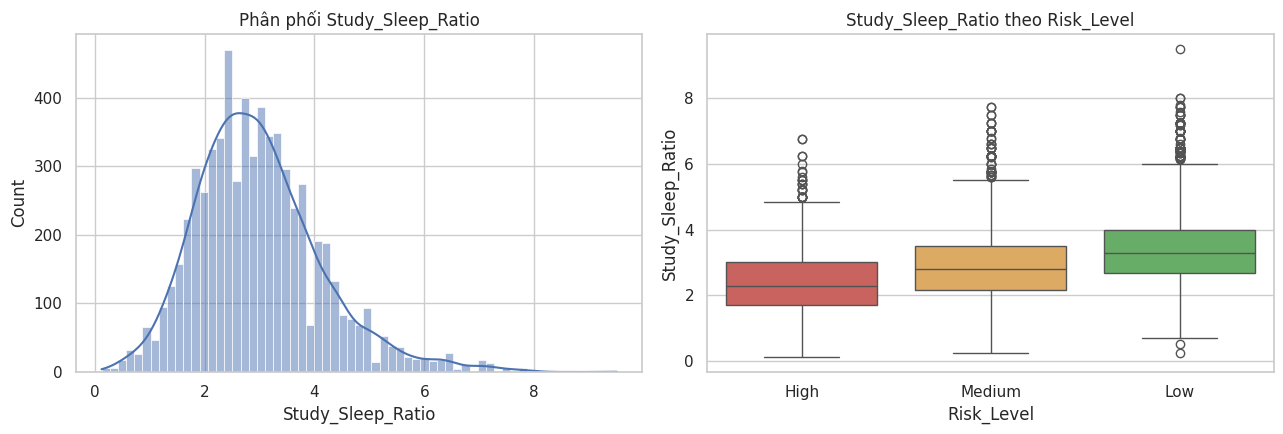

In [23]:
# Kiểm tra Study_Sleep_Ratio đúng công thức Hours_Studied / Sleep_Hours
calc = df["Hours_Studied"] / df["Sleep_Hours"]
print("Study_Sleep_Ratio khớp công thức:", np.allclose(calc, df["Study_Sleep_Ratio"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["Study_Sleep_Ratio"], kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Phân phối Study_Sleep_Ratio")
sns.boxplot(data=df, x=TARGET, y="Study_Sleep_Ratio", order=RISK_ORDER, hue=TARGET,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Study_Sleep_Ratio theo Risk_Level")
plt.tight_layout()
save_fig("11_study_sleep_ratio")
plt.show()

print(df[["Hours_Studied", "Sleep_Hours", "Study_Sleep_Ratio", "Exam_Score"]].corr()["Exam_Score"].round(3))

In [24]:
cat_stats = df.groupby("Attendance_Category").agg(
    n=("Exam_Score", "size"),
    attendance_min=("Attendance", "min"),
    attendance_max=("Attendance", "max"),
    mean_score=("Exam_Score", "mean"),
    high_risk_pct=(TARGET, lambda s: (s == "High").mean() * 100),
).loc[["Low", "Medium", "High"]].round(2)
print("=== Attendance_Category ===")
print(cat_stats)

=== Attendance_Category ===
                        n  attendance_min  ...  mean_score  high_risk_pct
Attendance_Category                        ...                           
Low                  1573              60  ...       64.21          56.13
Medium               2523              70  ...       66.68          20.10
High                 2510              85  ...       69.68           2.47

[3 rows x 5 columns]


**Nhận xét:** `Study_Sleep_Ratio` có tương quan khá với điểm thi, nhưng phần lớn thông tin đến từ `Hours_Studied` (cặp này tương quan ~0.77). `Attendance_Category` tách nhóm nguy cơ rõ rệt (xem mục 6) nhưng chỉ là phiên bản rời rạc hóa của `Attendance`, nên không đưa vào mô hình.

## 12. Feature Evaluation Summary (4-Panel Overview)

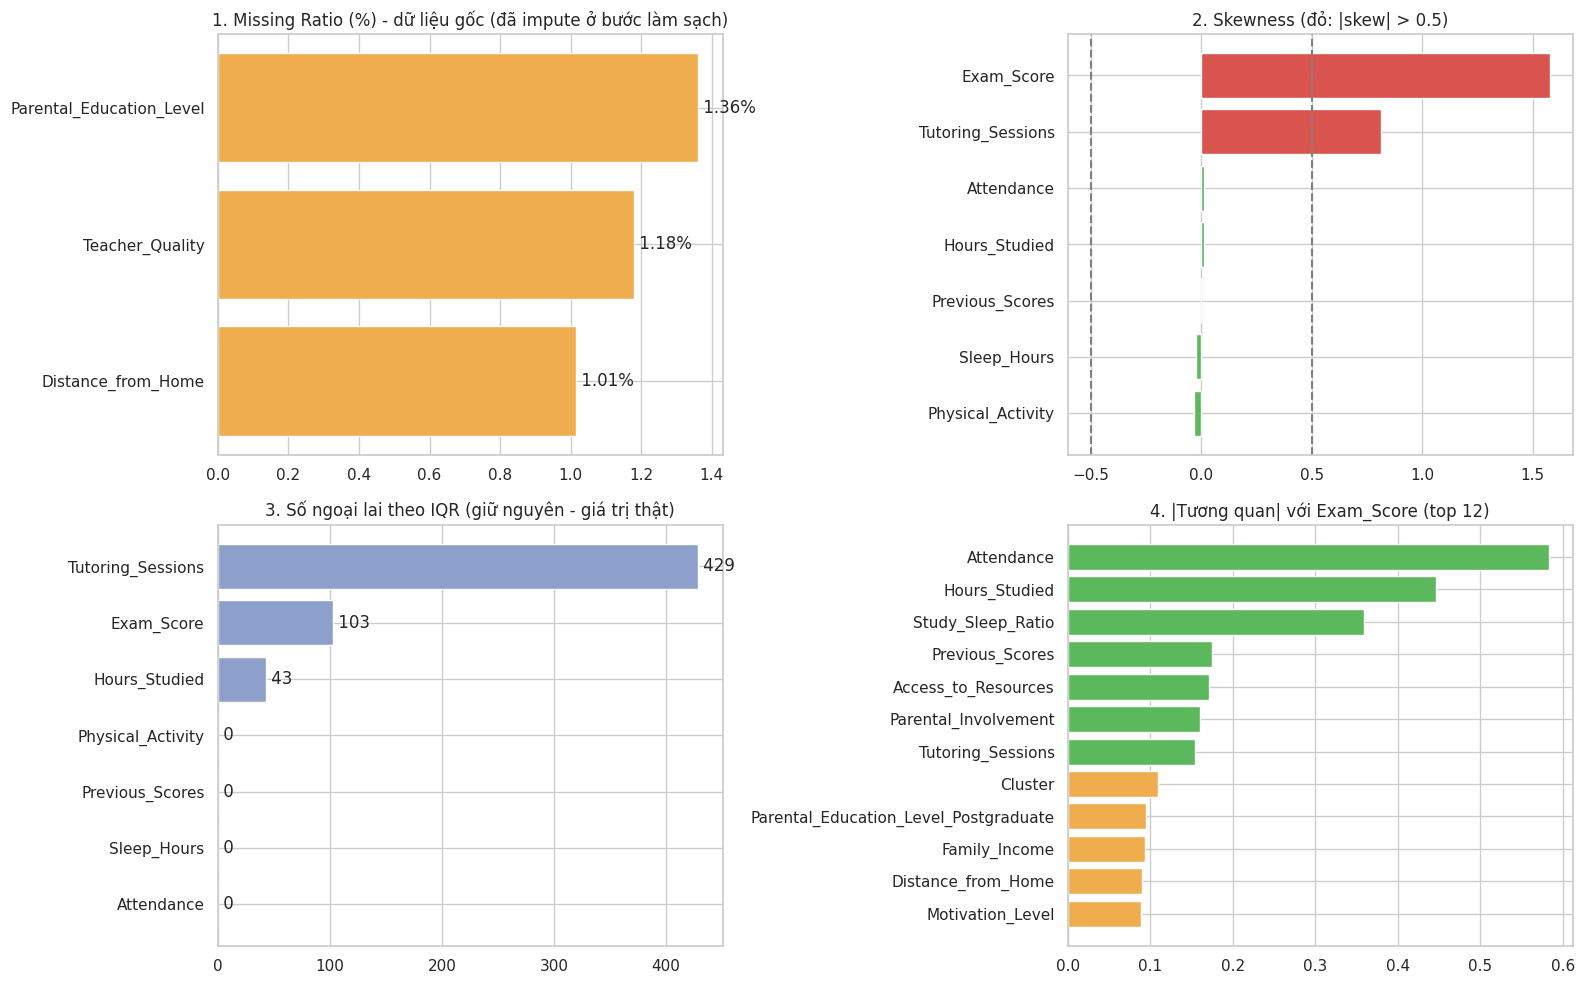

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Missing ratio (dữ liệu gốc)
ax = axes[0, 0]
if raw is not None:
    miss_ratio = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
    miss_ratio = miss_ratio[miss_ratio > 0]
    ax.barh(miss_ratio.index[::-1], miss_ratio.values[::-1], color="#f0ad4e")
    ax.set_title("1. Missing Ratio (%) - dữ liệu gốc (đã impute ở bước làm sạch)")
    for i, v in enumerate(miss_ratio.values[::-1]):
        ax.text(v, i, f" {v:.2f}%", va="center")
else:
    ax.text(0.5, 0.5, "Không có file raw", ha="center")

# 2. Skewness
ax = axes[0, 1]
skew = df[NUM_COLS].skew().sort_values()
ax.barh(skew.index, skew.values, color=["#d9534f" if abs(v) > 0.5 else "#5cb85c" for v in skew.values])
ax.axvline(0.5, color="gray", ls="--"); ax.axvline(-0.5, color="gray", ls="--")
ax.set_title("2. Skewness (đỏ: |skew| > 0.5)")

# 3. Outliers (IQR)
ax = axes[1, 0]
out_counts = {}
for col in NUM_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3 - q1
    out_counts[col] = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
oc = pd.Series(out_counts).sort_values()
ax.barh(oc.index, oc.values, color="#8da0cb")
ax.set_title("3. Số ngoại lai theo IQR (giữ nguyên - giá trị thật)")
for i, v in enumerate(oc.values):
    ax.text(v, i, f" {v}", va="center")

# 4. Tương quan với target
ax = axes[1, 1]
tc = corr_target.abs().sort_values().tail(12)
ax.barh(tc.index, tc.values, color=["#5cb85c" if v > 0.15 else "#f0ad4e" if v > 0.05 else "#d9534f" for v in tc.values])
ax.set_title("4. |Tương quan| với Exam_Score (top 12)")

plt.tight_layout()
save_fig("12_feature_evaluation_4panel")
plt.show()

| Tiêu chí | Kết quả | Đề xuất cho Modeling |
|---|---|---|
| **Missing** | 3 cột phân loại thiếu ~1% mỗi cột (dữ liệu gốc), 0% sau khi làm sạch | Không cần xử lý thêm |
| **Skewness** | Chỉ `Exam_Score` và `Tutoring_Sessions` lệch rõ | Không bắt buộc biến đổi với Logistic Regression / mô hình cây |
| **Outliers** | Ngoại lai IQR đều là giá trị thật | Giữ nguyên |
| **Target correlation** | Mạnh: `Attendance`, `Hours_Studied`; yếu: `Sleep_Hours`, `Physical_Activity`, `Gender`, `School_Type` | Chọn feature có \|r\| > 0.05 |

## 13. Business Insights & Executive Dashboard

In [26]:
counts = df[TARGET].value_counts()
top_corr = corr_target.abs().sort_values(ascending=False)
ac = df.groupby("Attendance_Category")[TARGET].apply(lambda s: (s == "High").mean() * 100)
cl = df.groupby("Cluster")[TARGET].apply(lambda s: (s == "High").mean() * 100)

print("=" * 62)
print("   BUSINESS INSIGHTS - DỰ ĐOÁN & CẢNH BÁO SỚM HỌC TẬP KÉM")
print("=" * 62)
print(f"\n1. Quy mô: {len(df):,} sinh viên; {counts['High']:,} ({counts['High']/len(df)*100:.1f}%) thuộc nhóm nguy cơ CAO.")
print(f"2. Yếu tố ảnh hưởng nhất: {top_corr.index[0]} (|r|={top_corr.iloc[0]:.2f}) và {top_corr.index[1]} (|r|={top_corr.iloc[1]:.2f}).")
print(f"3. Chuyên cần < 70%: {ac['Low']:.1f}% sinh viên nguy cơ cao; chuyên cần >= 85%: chỉ {ac['High']:.1f}%.")
print(f"4. Giờ ngủ gần như không liên quan đến điểm (r = {df['Sleep_Hours'].corr(df['Exam_Score']):.2f}).")
print(f"5. Cụm nguy cơ cao nhất: Cluster {cl.idxmax()} ({cl.max():.1f}% High); thấp nhất: Cluster {cl.idxmin()} ({cl.min():.1f}% High).")
print("\n>>> Khuyến nghị can thiệp: ưu tiên theo dõi chuyên cần và khuyến khích tăng giờ tự học.")
print("    Các yếu tố gia đình/trường học (hỗ trợ học liệu, phụ huynh quan tâm) có ảnh hưởng nhỏ hơn nhưng cùng chiều.")

   BUSINESS INSIGHTS - DỰ ĐOÁN & CẢNH BÁO SỚM HỌC TẬP KÉM

1. Quy mô: 6,606 sinh viên; 1,452 (22.0%) thuộc nhóm nguy cơ CAO.
2. Yếu tố ảnh hưởng nhất: Attendance (|r|=0.58) và Hours_Studied (|r|=0.45).
3. Chuyên cần < 70%: 56.1% sinh viên nguy cơ cao; chuyên cần >= 85%: chỉ 2.5%.
4. Giờ ngủ gần như không liên quan đến điểm (r = -0.02).
5. Cụm nguy cơ cao nhất: Cluster 0 (36.2% High); thấp nhất: Cluster 1 (4.7% High).

>>> Khuyến nghị can thiệp: ưu tiên theo dõi chuyên cần và khuyến khích tăng giờ tự học.
    Các yếu tố gia đình/trường học (hỗ trợ học liệu, phụ huynh quan tâm) có ảnh hưởng nhỏ hơn nhưng cùng chiều.


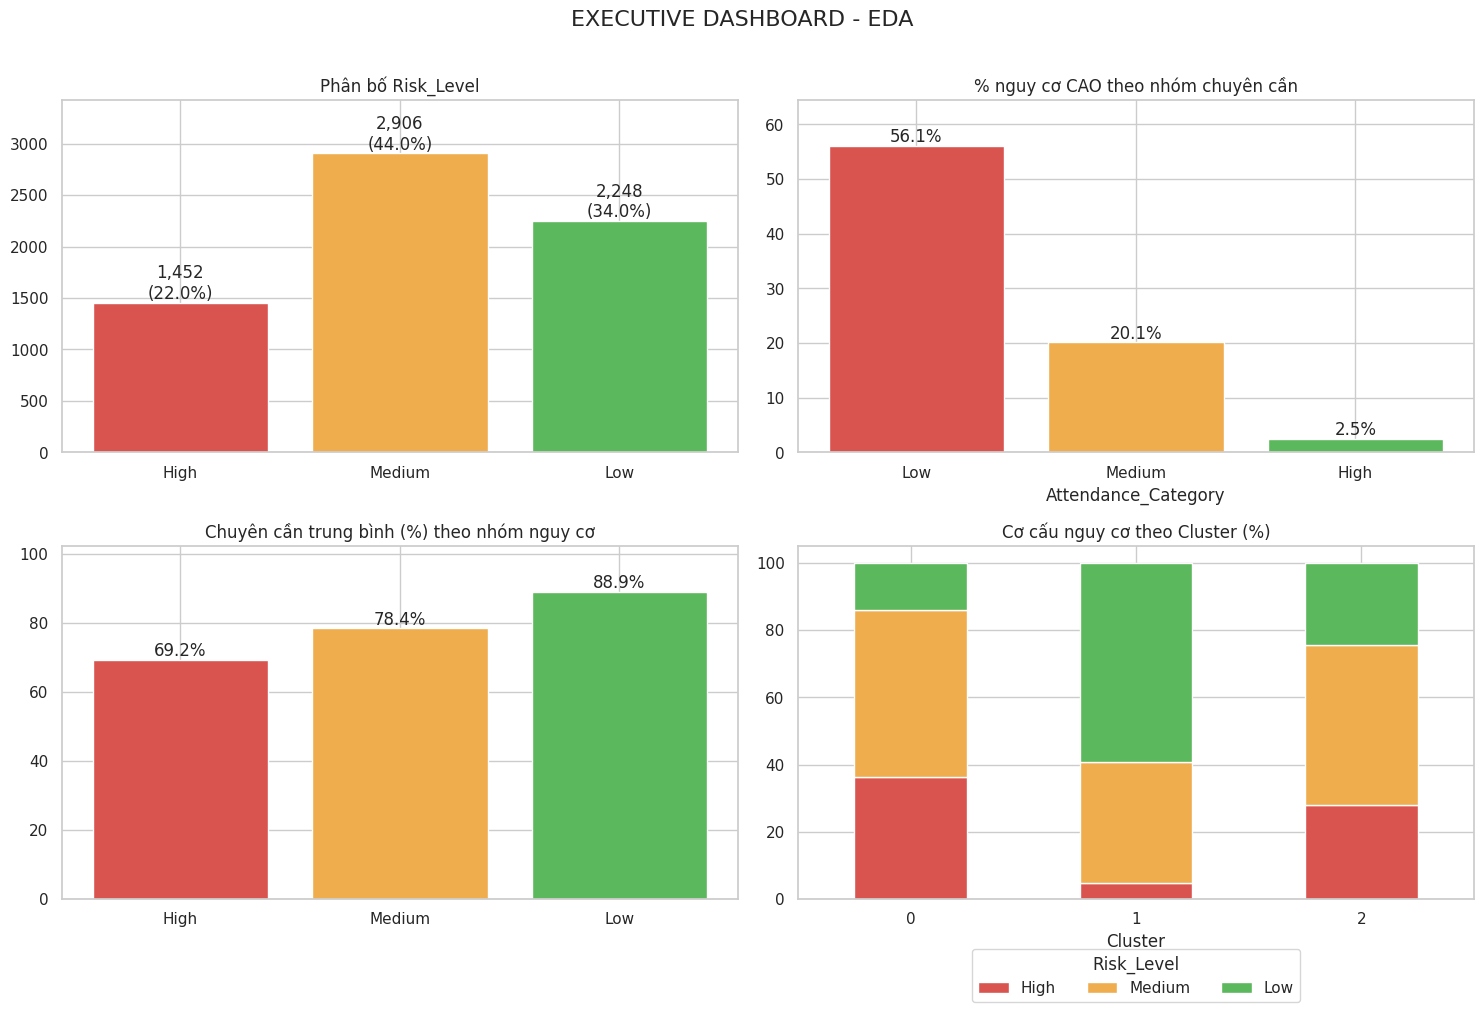

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Phân bố Risk_Level
c = df[TARGET].value_counts().reindex(RISK_ORDER)
axes[0, 0].bar(c.index, c.values, color=[PALETTE[x] for x in c.index])
axes[0, 0].set_title("Phân bố Risk_Level")
for i, v in enumerate(c.values):
    axes[0, 0].text(i, v, f"{v:,}\n({v / len(df) * 100:.1f}%)", ha="center", va="bottom")
axes[0, 0].set_ylim(0, c.max() * 1.18)

# 2. Tỷ lệ High theo nhóm chuyên cần
a = ac.loc[["Low", "Medium", "High"]]
axes[0, 1].bar(a.index, a.values, color=["#d9534f", "#f0ad4e", "#5cb85c"])
axes[0, 1].set_title("% nguy cơ CAO theo nhóm chuyên cần")
axes[0, 1].set_xlabel("Attendance_Category")
for i, v in enumerate(a.values):
    axes[0, 1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")
axes[0, 1].set_ylim(0, a.max() * 1.15)

# 3. Chuyên cần trung bình theo nhóm nguy cơ
m = df.groupby(TARGET)["Attendance"].mean().loc[RISK_ORDER]
axes[1, 0].bar(m.index, m.values, color=[PALETTE[x] for x in m.index])
for i, v in enumerate(m.values):
    axes[1, 0].text(i, v, f"{v:.1f}%", ha="center", va="bottom")
axes[1, 0].set_ylim(0, m.max() * 1.15)
axes[1, 0].set_title("Chuyên cần trung bình (%) theo nhóm nguy cơ")

# 4. Risk theo cụm
ct3 = pd.crosstab(df["Cluster"], df[TARGET], normalize="index")[RISK_ORDER] * 100
ct3.plot(kind="bar", stacked=True, ax=axes[1, 1], color=[PALETTE[x] for x in RISK_ORDER], rot=0)
axes[1, 1].set_title("Cơ cấu nguy cơ theo Cluster (%)")
axes[1, 1].legend(title=TARGET, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.suptitle("EXECUTIVE DASHBOARD - EDA", fontsize=16, y=1.01)
plt.tight_layout()
save_fig("13_executive_dashboard")
plt.show()

---
### Kết luận EDA & bàn giao cho bước Modeling
1. **Features chính:** `Attendance`, `Hours_Studied`, `Previous_Scores`, `Tutoring_Sessions`, cùng nhóm yếu tố gia đình/trường học.
2. **Không dùng:** `Exam_Score` (data leakage), `Attendance_Category` (trùng `Attendance`).
3. **Imbalance nhẹ (≈ 2 : 1):** dùng `stratify`, theo dõi Recall của lớp High.
4. **Giới hạn của dữ liệu:** dataset không có các biến `Social Media`, `Gaming`, `Stress`, `Part-time Job` như đề cương; các yếu tố lối sống có trong dữ liệu (giờ ngủ, vận động) gần như không ảnh hưởng đến điểm.

**Tiếp theo:** `05_modeling.ipynb` (so sánh mô hình, tuning, SHAP) và `06_risk_warning.ipynb` (Risk Score, Early Warning, Recommendation, Dashboard).